In [17]:
import os
import glob
import random
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from sklearn.model_selection import train_test_split

In [18]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
frame_root = "/content/drive/MyDrive/processed_frames_v2"

In [21]:
def collect_video_dirs(frame_root):
    items = []

    for label_name, label_idx in [("REAL", 0), ("FAKE", 1)]:
        label_root = os.path.join(frame_root, label_name)

        part_dirs = glob.glob(os.path.join(label_root, "*"))

        for part_dir in part_dirs:
            if not os.path.isdir(part_dir):
                continue

            video_dirs = glob.glob(os.path.join(part_dir, "*"))

            for video_dir in video_dirs:
                if not os.path.isdir(video_dir):
                    continue

                frame_paths = glob.glob(os.path.join(video_dir, "*.jpg"))

                if len(frame_paths) > 0:
                    items.append((video_dir, label_idx))

    return items


video_items = collect_video_dirs(frame_root)

print("전체 영상 폴더 수:", len(video_items))
print("REAL 영상 수:", sum(1 for _, label in video_items if label == 0))
print("FAKE 영상 수:", sum(1 for _, label in video_items if label == 1))

전체 영상 폴더 수: 2010
REAL 영상 수: 1005
FAKE 영상 수: 1005


In [22]:
labels = [label for _, label in video_items]

train_items, val_items = train_test_split(
    video_items,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("train 영상 수:", len(train_items))
print("val 영상 수:", len(val_items))

print("train REAL:", sum(1 for _, label in train_items if label == 0))
print("train FAKE:", sum(1 for _, label in train_items if label == 1))
print("val REAL:", sum(1 for _, label in val_items if label == 0))
print("val FAKE:", sum(1 for _, label in val_items if label == 1))

train 영상 수: 1608
val 영상 수: 402
train REAL: 804
train FAKE: 804
val REAL: 201
val FAKE: 201


In [23]:
class DeepfakeDataset(Dataset):
    def __init__(self, video_items, transform=None):
        self.transform = transform
        self.data = []

        for video_dir, label in video_items:
            frame_paths = glob.glob(os.path.join(video_dir, "*.jpg"))

            for frame_path in frame_paths:
                self.data.append((frame_path, label))

        print(f"전체 이미지 수: {len(self.data)}")
        real_count = sum(1 for _, label in self.data if label == 0)
        fake_count = sum(1 for _, label in self.data if label == 1)
        print(f"REAL: {real_count}장 | FAKE: {fake_count}장")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)

In [24]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [25]:
train_dataset = DeepfakeDataset(train_items, transform=train_transform)
val_dataset = DeepfakeDataset(val_items, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"train 이미지 수: {len(train_dataset)}")
print(f"val 이미지 수: {len(val_dataset)}")
print(f"train 배치 수: {len(train_loader)}")
print(f"val 배치 수: {len(val_loader)}")

전체 이미지 수: 12320
REAL: 6194장 | FAKE: 6126장
전체 이미지 수: 3045
REAL: 1528장 | FAKE: 1517장
train 이미지 수: 12320
val 이미지 수: 3045
train 배치 수: 385
val 배치 수: 96


In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

사용 디바이스: cuda


In [27]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [28]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for imgs, labels in tqdm(loader, desc="train"):
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)

        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    acc = correct / total

    return avg_loss, acc

In [29]:
def validate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="val"):
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * imgs.size(0)

            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    acc = correct / total

    return avg_loss, acc

In [30]:
num_epochs = 10
best_val_acc = 0

save_path = "/content/drive/MyDrive/resnet50_best.pth"

for epoch in range(num_epochs):
    print(f"\n[Epoch {epoch+1}/{num_epochs}]")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    print(
        f"train loss: {train_loss:.4f} | "
        f"train acc: {train_acc:.4f} | "
        f"val loss: {val_loss:.4f} | "
        f"val acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path)
        print(f"최고 모델 저장 | val acc: {val_acc:.4f}")

print("\nResNet50 학습 완료")
print(f"최고 val acc: {best_val_acc:.4f}")
print(f"저장 경로: {save_path}")


[Epoch 1/10]


val: 100%|██████████| 96/96 [00:15<00:00,  6.23it/s]


train loss: 0.5175 | train acc: 0.7428 | val loss: 0.4521 | val acc: 0.7724
최고 모델 저장 | val acc: 0.7724

[Epoch 2/10]


val: 100%|██████████| 96/96 [00:15<00:00,  6.26it/s]


train loss: 0.3398 | train acc: 0.8531 | val loss: 0.4007 | val acc: 0.8217
최고 모델 저장 | val acc: 0.8217

[Epoch 3/10]


...

train loss: 0.0963 | train acc: 0.9625 | val loss: 0.4270 | val acc: 0.8535
최고 모델 저장 | val acc: 0.8535

[Epoch 9/10]


val: 100%|██████████| 96/96 [00:15<00:00,  6.10it/s]


train loss: 0.0845 | train acc: 0.9682 | val loss: 0.5085 | val acc: 0.8519

[Epoch 10/10]


val: 100%|██████████| 96/96 [00:15<00:00,  6.29it/s]

train loss: 0.0736 | train acc: 0.9726 | val loss: 0.6267 | val acc: 0.8230

ResNet50 학습 완료
최고 val acc: 0.8535
저장 경로: /content/drive/MyDrive/resnet50_best.pth


In [31]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

save_path = "/content/drive/MyDrive/resnet50_best.pth"

best_model = models.resnet50(weights=None)
best_model.fc = nn.Linear(best_model.fc.in_features, 2)

best_model.load_state_dict(torch.load(save_path, map_location=device))
best_model = best_model.to(device)
best_model.eval()

print("best model 불러오기 완료")

best model 불러오기 완료


In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def evaluate_frame_level(model, loader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Frame-level Evaluation"):
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    print("Frame-level Accuracy:", acc)
    print("Frame-level Precision:", precision)
    print("Frame-level Recall:", recall)
    print("Frame-level F1-score:", f1)

    print("\nClassification Report")
    print(classification_report(
        all_labels,
        all_preds,
        target_names=["REAL", "FAKE"],
        zero_division=0
    ))

    return all_labels, all_preds, all_probs


frame_labels, frame_preds, frame_probs = evaluate_frame_level(
    best_model,
    val_loader,
    device
)

Frame-level Evaluation: 100%|██████████| 96/96 [00:15<00:00,  6.18it/s]

Frame-level Accuracy: 0.8535303776683087
Frame-level Precision: 0.8426103646833013
Frame-level Recall: 0.8681608437705999
Frame-level F1-score: 0.8551948051948052

Classification Report
              precision    recall  f1-score   support

        REAL       0.87      0.84      0.85      1528
        FAKE       0.84      0.87      0.86      1517

    accuracy                           0.85      3045
   macro avg       0.85      0.85      0.85      3045
weighted avg       0.85      0.85      0.85      3045



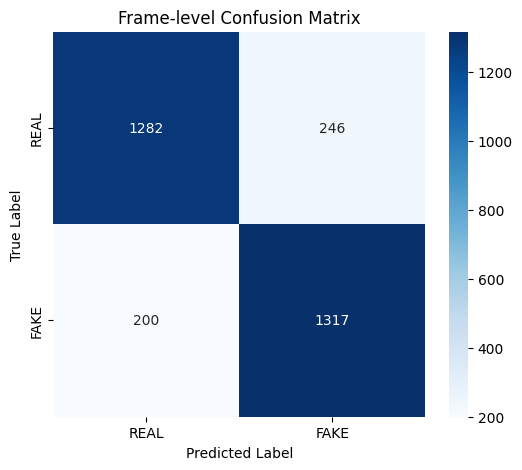

In [33]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(frame_labels, frame_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["REAL", "FAKE"],
    yticklabels=["REAL", "FAKE"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Frame-level Confusion Matrix")
plt.show()

In [34]:
import numpy as np
from PIL import Image
import glob
import os

def predict_video_folder(model, video_dir, transform, device, threshold=0.5):
    model.eval()

    frame_paths = glob.glob(os.path.join(video_dir, "*.jpg"))

    if len(frame_paths) == 0:
        return None

    fake_probs = []

    with torch.no_grad():
        for frame_path in frame_paths:
            img = Image.open(frame_path).convert("RGB")
            img = transform(img).unsqueeze(0).to(device)

            output = model(img)
            prob = torch.softmax(output, dim=1)

            fake_prob = prob[0][1].item()
            fake_probs.append(fake_prob)

    mean_fake_prob = np.mean(fake_probs)

    if mean_fake_prob >= threshold:
        pred_label = 1
        pred_name = "FAKE"
    else:
        pred_label = 0
        pred_name = "REAL"

    return {
        "video_dir": video_dir,
        "num_frames": len(frame_paths),
        "mean_fake_prob": mean_fake_prob,
        "pred_label": pred_label,
        "pred_name": pred_name
    }

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def evaluate_video_level(model, video_items, transform, device, threshold=0.5):
    y_true = []
    y_pred = []
    results = []

    for video_dir, true_label in tqdm(video_items, desc="Video-level Evaluation"):
        result = predict_video_folder(
            model=model,
            video_dir=video_dir,
            transform=transform,
            device=device,
            threshold=threshold
        )

        if result is None:
            continue

        result["true_label"] = true_label
        result["true_name"] = "REAL" if true_label == 0 else "FAKE"

        y_true.append(true_label)
        y_pred.append(result["pred_label"])
        results.append(result)

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print("Video-level Accuracy:", acc)
    print("Video-level Precision:", precision)
    print("Video-level Recall:", recall)
    print("Video-level F1-score:", f1)

    print("\nClassification Report")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["REAL", "FAKE"],
        zero_division=0
    ))

    return results, y_true, y_pred


video_results, video_labels, video_preds = evaluate_video_level(
    best_model,
    val_items,
    val_transform,
    device,
    threshold=0.5
)

Video-level Evaluation: 100%|██████████| 402/402 [00:36<00:00, 11.12it/s]

Video-level Accuracy: 0.9054726368159204
Video-level Precision: 0.893719806763285
Video-level Recall: 0.9203980099502488
Video-level F1-score: 0.9068627450980392

Classification Report
              precision    recall  f1-score   support

        REAL       0.92      0.89      0.90       201
        FAKE       0.89      0.92      0.91       201

    accuracy                           0.91       402
   macro avg       0.91      0.91      0.91       402
weighted avg       0.91      0.91      0.91       402



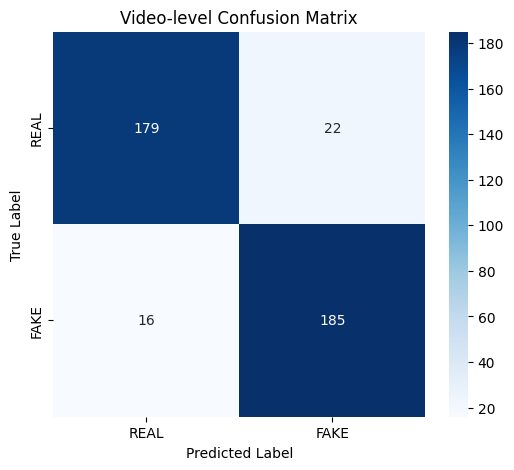

In [36]:
cm_video = confusion_matrix(video_labels, video_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_video,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["REAL", "FAKE"],
    yticklabels=["REAL", "FAKE"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Video-level Confusion Matrix")
plt.show()

In [37]:
import pandas as pd

df_results = pd.DataFrame(video_results)

csv_path = "/content/drive/MyDrive/video_level_results.csv"
df_results.to_csv(csv_path, index=False)

print("영상 단위 결과 저장 완료:", csv_path)
df_results.head()

영상 단위 결과 저장 완료: /content/drive/MyDrive/video_level_results.csv


,video_dir,num_frames,mean_fake_prob,pred_label,pred_name,true_label,true_name
0,/content/drive/MyDrive/processed_frames_v2/FAK...,8,4.930974e-01,0,REAL,1,FAKE
1,/content/drive/MyDrive/processed_frames_v2/REA...,8,3.301592e-01,0,REAL,0,REAL
2,/content/drive/MyDrive/processed_frames_v2/REA...,8,7.674873e-01,1,FAKE,0,REAL
3,/content/drive/MyDrive/processed_frames_v2/REA...,8,3.413148e-07,0,REAL,0,REAL
4,/content/drive/MyDrive/processed_frames_v2/FAK...,8,7.665908e-01,1,FAKE,1,FAKE


In [38]:
correct_cases = df_results[df_results["pred_label"] == df_results["true_label"]]
wrong_cases = df_results[df_results["pred_label"] != df_results["true_label"]]

print("정분류 영상 수:", len(correct_cases))
print("오분류 영상 수:", len(wrong_cases))

정분류 영상 수: 364
오분류 영상 수: 38


In [39]:
wrong_cases.head()

,video_dir,num_frames,mean_fake_prob,pred_label,pred_name,true_label,true_name
0,/content/drive/MyDrive/processed_frames_v2/FAK...,8,0.493097,0,REAL,1,FAKE
2,/content/drive/MyDrive/processed_frames_v2/REA...,8,0.767487,1,FAKE,0,REAL
12,/content/drive/MyDrive/processed_frames_v2/FAK...,7,0.027671,0,REAL,1,FAKE
13,/content/drive/MyDrive/processed_frames_v2/REA...,6,0.510682,1,FAKE,0,REAL
19,/content/drive/MyDrive/processed_frames_v2/REA...,6,0.694450,1,FAKE,0,REAL


In [40]:
def show_video_frames(video_dir, title="", num_images=8):
    frame_paths = glob.glob(os.path.join(video_dir, "*.jpg"))

    if len(frame_paths) == 0:
        print("프레임 없음")
        return

    num_images = min(num_images, len(frame_paths))
    sample_paths = frame_paths[:num_images]

    cols = 4
    rows = (num_images + cols - 1) // cols

    plt.figure(figsize=(16, rows * 4))

    for i, path in enumerate(sample_paths):
        img = Image.open(path)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(os.path.basename(path))
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

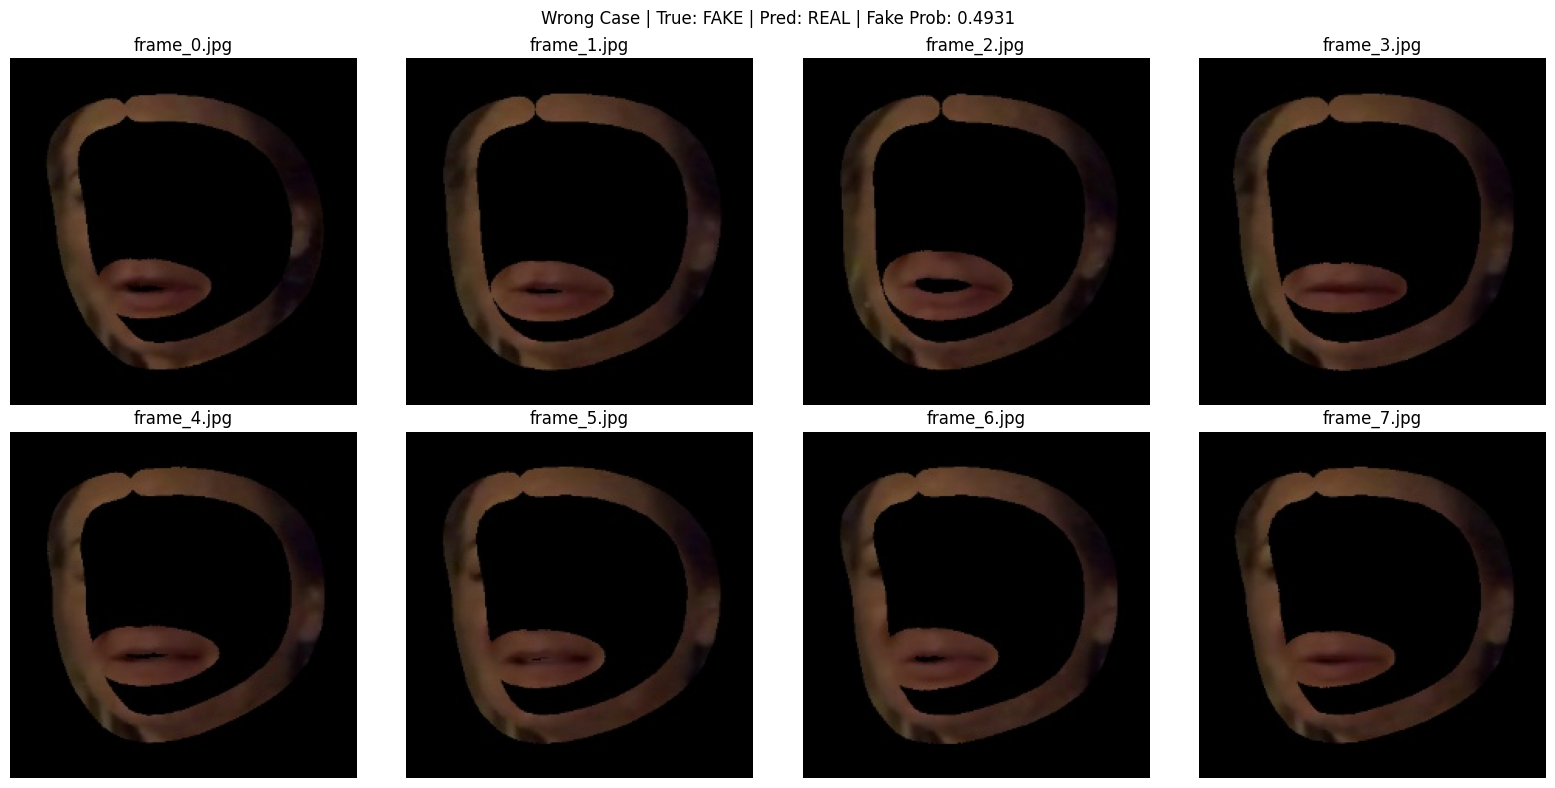

In [41]:
if len(wrong_cases) > 0:
    sample_wrong = wrong_cases.iloc[0]

    show_video_frames(
        sample_wrong["video_dir"],
        title=f"Wrong Case | True: {sample_wrong['true_name']} | Pred: {sample_wrong['pred_name']} | Fake Prob: {sample_wrong['mean_fake_prob']:.4f}"
    )
else:
    print("오분류 사례가 없습니다.")